In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3

In [2]:
import pandas as pd

df = pd.read_excel("customer_churn_data_raw.xlsx")

In [3]:
df.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12,travel,NaN
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23,NaN,NaN
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15,movie,NaN
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30,NaN,NaN
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05,drama,NaN


In [4]:
df.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19,NaN,NaN
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02,NaN,NaN
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30,NaN,NaN
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14,NaN,NaN
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06,NaN,NaN


In [5]:
df.shape

(21, 8)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   customerid  21 non-null     str           
 1   name        21 non-null     str           
 2   country     18 non-null     str           
 3   state       21 non-null     str           
 4   gender      21 non-null     str           
 5   dob         21 non-null     datetime64[us]
 6   interests   4 non-null      str           
 7   pincode     0 non-null      float64       
dtypes: datetime64[us](1), float64(1), str(6)
memory usage: 2.2 KB


In [7]:
df.describe()

,dob,pincode
count,21,0.0
mean,1989-08-26 12:34:17.142857,NaN
min,1976-09-21 00:00:00,NaN
25%,1982-04-12 00:00:00,NaN
50%,1990-05-05 00:00:00,NaN
75%,1995-11-23 00:00:00,NaN
max,2004-12-01 00:00:00,NaN
std,NaN,NaN


In [8]:
# import database/data

In [9]:
conn = sqlite3.connect('customer_churn.db')
sql_query = """
select name from sqlite_master where type='table'
"""
table = pd.read_sql(sql_query, conn)

# Yithe badal kela ahe:
tables = table['name'].tolist()

for table_name in tables:
    df = pd.read_sql(f"select * from {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"created dataframe: df_{table_name}")

conn.close()

created dataframe: df_db_customer
created dataframe: df_db_subscription
created dataframe: df_db_support


In [10]:
conn = sqlite3.connect('customer_churn.db')
for table_name in tables:
    print(f"\nTable Name: {table_name}")
columns_query = f"PRAGMA table_info({table_name});"
columns = pd.read_sql(columns_query, conn)

print("Columns:")
print(columns["name"].tolist())

# Close connection
conn.close()


Table Name: db_customer

Table Name: db_subscription

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [11]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [12]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,NaN,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,NaN,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,NaN,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,NaN,None


In [13]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 2.5+ KB


In [14]:
# drop pincode & interest
# rename - name 
# change data type - dob
# fix missing values -  country 
# data standardization - gender 

In [15]:
df_db_customer.rename(columns = {'name': 'customer_name'},inplace=True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00,NaN,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,NaN,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,NaN,None
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00,NaN,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,NaN,None


In [16]:
# df_db_customer.drop(df_db_customer.columns[-2:],axis=1)
# df_db_customer.drop(df_db_customer.columns[6:],axis=1)
df_db_customer.drop(columns=['interests','pincode'],inplace=True)

In [17]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 895.0+ bytes


In [19]:
# change data type - dob
df_db_customer['dob']=pd.to_datetime(df_db_customer['dob'])

In [20]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     str           
 1   customer_name  21 non-null     str           
 2   country        18 non-null     str           
 3   state          21 non-null     str           
 4   gender         21 non-null     str           
 5   dob            21 non-null     datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 1.8 KB


In [21]:
# data standardization - gender 
df_db_customer['gender'].unique()

<ArrowStringArray>
['Male', 'Female', 'Women', 'Men']
Length: 4, dtype: str

In [22]:
df_db_customer['gender']=df_db_customer['gender'].replace({'Men':'Male','Women':'Female'})

In [23]:
df_db_customer['gender'].unique()

<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

In [24]:
# fix missing values -  country 
df_db_customer[df_db_customer['country'].isna()]       # true means value are null 

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [25]:
# country and state - unique value pair 
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [26]:
df_db_customer['country']

0     India
1     India
2     India
3     India
4     India
5     India
6     India
7     India
8     Nepal
9     Nepal
10    India
11    India
12    India
13    India
14    India
15    India
16    India
17    India
18    India
19    India
20    India
Name: country, dtype: str

In [27]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [28]:
df_db_customer[['country','state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,India,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,Nepal,Kathmandu
9,Nepal,Kathmandu


In [29]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [30]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 3.1 KB


In [31]:
date_col= ['subscription_start_date','renewal_date','cancellation_date']
df_db_subscription[date_col]=df_db_subscription[date_col].apply(pd.to_datetime)

In [32]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 2.7 KB


In [33]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [34]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 895.0+ bytes


In [35]:
df_db_support.drop(columns=['col_1', 'comment'],inplace=True)

In [36]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customerid      9 non-null      str  
 1   complaint_date  9 non-null      str  
 2   escalations     9 non-null      str  
 3   csat_score      9 non-null      int64
dtypes: int64(1), str(3)
memory usage: 690.0 bytes


In [37]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [38]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 519.0 bytes


### features engineering 

In [39]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 2.7 KB


In [40]:
# create new columns - churn flag 
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [41]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [42]:
# first fix support table duplicates  then merge 
df=(df_db_subscription
        .merge(df_db_customer , on ='customerid', how='left')
        .merge(df_db_support , on ='customerid', how='left')) 

In [43]:
df.shape

(23, 20)

In [44]:
df_db_subscription.shape

(21, 12)

In [45]:
df_db_subscription['customerid'].nunique()

21

In [46]:
df_db_customer['customerid'].nunique()

21

In [47]:
df_db_support['customerid'].nunique()

7

In [48]:
df_db_support['customerid'].size

9

In [49]:
df_db_support.head()   # complaint_date create multiply same customer id 

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30


In [50]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [51]:
df_db_support.groupby('customerid')['customerid'].transform('count')

0    2
1    2
2    1
3    1
4    1
5    1
6    1
7    2
8    2
Name: customerid, dtype: int64

In [52]:
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [53]:
# df_db_support['complaint_count'] = (
#     df_db_support.groupby('customerid')['customerid'].transform('count')
# )

In [54]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [55]:
df_db_support=df_db_support.sort_values('complaint_count').drop_duplicates('customerid',keep='last')	

In [56]:
df_db_support['customerid'].size

7

In [57]:
# df merge 
df=(df_db_subscription
        .merge(df_db_customer , on ='customerid', how='left')
        .merge(df_db_support , on ='customerid', how='left'))  

In [58]:
df.shape

(21, 21)

In [59]:
df.to_csv("exported_churn_data.csv",index=False)

### Data Analysis 

#### churn Rate 

In [60]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [61]:
df['churn_flag'].mean()

np.float64(0.2857142857142857)

In [62]:
df['churn_flag'].mean() * 100

np.float64(28.57142857142857)

In [63]:
Churn_rate = df['churn_flag'].mean() * 100
print("Churn Rate = ", round(Churn_rate,2), "%")

Churn Rate =  28.57 %


In [64]:
# Retenion Rate 
retenion_rate =100-Churn_rate
print("Retenion Rate = ", round(retenion_rate,2), "%")

Retenion Rate =  71.43 %


In [65]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0,2.0


In [66]:
# churn by plan type 
df.groupby('plan_type')['churn_flag'].mean()

plan_type
Basic       0.600000
Premium     0.142857
Standard    0.222222
Name: churn_flag, dtype: float64

In [67]:
churn_by_plan=df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct')
print(churn_by_plan)


  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [68]:
# BASIC IS MOST CHURN
# churn by state + sum(revenu) & count of user --- home work
# churn by subscription + sum(revenu) & count of user --- home work

In [69]:
churn_by_state = (
    df.groupby('state')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))

print(churn_by_state)

           state  churn_rate_pct
0          Delhi           25.00
1      Karnataka          100.00
2      Kathmandu            0.00
3    Maharashtra            0.00
4      Meghalaya           66.67
5       Nagaland            0.00
6      Rajasthan            0.00
7      Telangana           50.00
8  Uttar Pradesh            0.00


In [70]:
# 1. Churn by State + Revenue/Charges + User Count
churn_by_state = (
    df.groupby('state')
      .agg(churn_rate_pct=('churn_flag', lambda x: x.mean() * 100),
           total_revenue=('monthly_charges', 'sum'),
           user_count=('customerid', 'nunique')
          ).reset_index())
churn_by_state['churn_rate_pct'] = churn_by_state['churn_rate_pct'].round(2)
print(churn_by_state)

           state  churn_rate_pct  total_revenue  user_count
0          Delhi           25.00          52.96           4
1      Karnataka          100.00          20.98           2
2      Kathmandu            0.00          20.98           2
3    Maharashtra            0.00          50.97           3
4      Meghalaya           66.67          42.97           3
5       Nagaland            0.00          22.99           1
6      Rajasthan            0.00          36.98           2
7      Telangana           50.00          30.98           2
8  Uttar Pradesh            0.00         115.98           2


In [71]:
#2. Churn by Subscription + Revenue + User Count
churn_by_subscription = (
    df.groupby('subscription_type')
      .agg(
          churn_rate_pct=('churn_flag', lambda x: x.mean() * 100),
          total_revenue=('monthly_charges', 'sum'),
          user_count=('customerid', 'nunique')
      )
      .reset_index())
churn_by_subscription['churn_rate_pct'] = (
    churn_by_subscription['churn_rate_pct'].round(2))
print(churn_by_subscription)

  subscription_type  churn_rate_pct  total_revenue  user_count
0           Organic            0.00         145.91           9
1              Paid           16.67         174.94           6
2          Refferal           83.33          74.94           6


In [72]:
print(df.columns.tolist())

['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score', 'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob', 'complaint_date', 'escalations', 'csat_score', 'complaint_count']


In [73]:
# arpu - average revenu  per user
arpu=df['monthly_charges'].mean()
print('ARPU =',round(arpu,2))

ARPU = 18.85


In [74]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [75]:
# average customer tenure 
# count of  days  ours user has used our  services : cancellation  date  else  current date 
#pd.Timestamp.today()
today =pd.Timestamp.today()

In [76]:
#- calculate customer age 
df['tenure_days']=np.where(df['cancellation_date'].notna(),
                      (df['cancellation_date']-df['subscription_start_date']).dt.days,
                      (today-df['subscription_start_date']).dt.days)
df.head()
                      
                      

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN,2032.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0,2.0,1501.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN,1417.0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN,2707.0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0,419.0


In [77]:
avg_tenure=df['tenure_days'].mean()
print("avg_tenure Days = ",round(avg_tenure),0)

avg_tenure Days =  1555 0


In [78]:
# revenu at risk - revenu at lost from churn users
df.iloc[df['churn_flag']==1]

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0,2.0,1501.0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0,419.0
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,mina,India,Meghalaya,Female,1976-09-21,2024-11-01,N,30.0,1.0,1142.0
11,0017-IUDMW,2023-03-17,Refferal,2024-03-17,Standard,Monthly,2024-05-01,Poor streaming quality,7.99,270,...,rangadevi,India,Karnataka,Female,1981-06-18,2024-04-10,Y,25.0,1.0,411.0
13,0019-EFAEP,2022-08-25,Refferal,2024-08-25,Basic,Monthly,2024-10-31,Switched to competitor,12.99,160,...,raju,India,Meghalaya,Female,1992-04-25,2024-09-27,Y,30.0,1.0,798.0
18,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,...,raghvendra,India,Telangana,Male,1983-12-30,2024-09-14,N,90.0,2.0,366.0


In [79]:
revenu_at_risk=df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print(" Revenu at Risk(Rs lakh) =" ,revenu_at_risk)

 Revenu at Risk(Rs lakh) = 73.94


In [80]:
# esclation Rate 
df['escalations'].nunique()

2

In [81]:
df['escalations'].unique()

<ArrowStringArray>
[nan, 'N', 'Y']
Length: 3, dtype: str

In [82]:
(df['escalations']=='Y').mean()

np.float64(0.14285714285714285)

In [83]:
escalations_rate=(df['escalations']=='Y').mean()*100
print("Escalations Rate =", round(escalations_rate,2),"%")

Escalations Rate = 14.29 %


In [84]:
# average of complaint per user 
# df['complaint_count'].sum()
avg_complaint=df['complaint_count'].sum() / df['customerid'].nunique()
print("Complaint Count =", round(avg_complaint,2))

Complaint Count = 0.43


In [85]:
# correlation escalation vs churn
df[['escalations','churn_flag']].dropna()

,escalations,churn_flag
1,N,1
4,Y,1
5,N,0
6,N,1
11,Y,1
13,Y,1
18,N,1


In [86]:
# unique user data no duplicate 
df[['customerid','escalations','churn_flag']].dropna()

,customerid,escalations,churn_flag
1,0003-MKNFE,N,1
4,0013-EXCHZ,Y,1
5,0013-MHZWF,N,0
6,0013-SMEOE,N,1
11,0017-IUDMW,Y,1
13,0019-EFAEP,Y,1
18,0022-TCJCI,N,1


In [87]:
df['escalations'] = np.where(df['escalations'] == 'Y',1,0) # encoding string to int type
# df[['customerid','escalations','churn_flag']].dropna()

In [88]:
df['escalations'] 

0     0
1     0
2     0
3     0
4     1
5     0
6     0
7     0
8     0
9     0
10    0
11    1
12    0
13    1
14    0
15    0
16    0
17    0
18    0
19    0
20    0
Name: escalations, dtype: int64

In [89]:
corr_df=df[['customerid','escalations','churn_flag']].dropna()
correlation=corr_df['escalations'].corr(df['churn_flag'])
print("correlation between escalation vs churn is  =",round(correlation,2))

correlation between escalation vs churn is  = 0.65


In [90]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days'],
      dtype='str')

In [91]:
df['churn_score'].head()

0    12
1    91
2    34
3     8
4    88
Name: churn_score, dtype: int64

In [92]:
# create  a column using existing col -check risk 
condition =[
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
]
choice=['low','mid','high']
df['churn_risk']=np.select(condition, choice ,default='unknow')

In [93]:
df[['churn_risk','csat_score']].head()

,churn_risk,csat_score
0,low,NaN
1,high,60.0
2,low,NaN
3,low,NaN
4,high,20.0


In [94]:
df[['churn_risk','csat_score']].tail()

,churn_risk,csat_score
16,mid,NaN
17,low,NaN
18,high,90.0
19,low,NaN
20,low,NaN


# data visualization  

### matplotlib

In [95]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,2032.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,0,60.0,2.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1417.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2707.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high


In [96]:
df_visual=df.copy()

In [97]:
df_visual.shape

(21, 23)

In [98]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='str')

In [99]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,2032.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,0,60.0,2.0,1501.0,high


In [100]:
# monthly churn trend(time series)

In [101]:
df_visual['cancellation_month']=df_visual['cancellation_date'].dt.to_period('M')

In [102]:
df_visual['cancellation_month']

0         NaT
1     2024-09
2         NaT
3         NaT
4     2024-02
5         NaT
6     2024-11
7         NaT
8         NaT
9         NaT
10        NaT
11    2024-05
12        NaT
13    2024-10
14        NaT
15        NaT
16        NaT
17        NaT
18    2024-09
19        NaT
20        NaT
Name: cancellation_month, dtype: period[M]

In [103]:
df_visual[df_visual['churn_flag']==1]

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk,cancellation_month
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23,2024-08-28,0,60.0,2.0,1501.0,high,2024-09
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high,2024-02
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,Meghalaya,Female,1976-09-21,2024-11-01,0,30.0,1.0,1142.0,high,2024-11
11,0017-IUDMW,2023-03-17,Refferal,2024-03-17,Standard,Monthly,2024-05-01,Poor streaming quality,7.99,270,...,Karnataka,Female,1981-06-18,2024-04-10,1,25.0,1.0,411.0,high,2024-05
13,0019-EFAEP,2022-08-25,Refferal,2024-08-25,Basic,Monthly,2024-10-31,Switched to competitor,12.99,160,...,Meghalaya,Female,1992-04-25,2024-09-27,1,30.0,1.0,798.0,high,2024-10
18,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,...,Telangana,Male,1983-12-30,2024-09-14,0,90.0,2.0,366.0,high,2024-09


In [104]:
churn_trend = df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()

In [105]:
churn_trend

cancellation_month
2024-02    1
2024-05    1
2024-09    2
2024-10    1
2024-11    1
Freq: M, dtype: int64

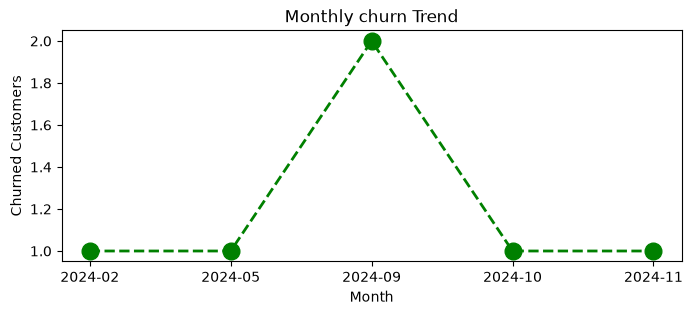

In [106]:
df_visual['cancellation_month']=df_visual['cancellation_date'].dt.to_period('M')
churn_trend = df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()
plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color='green', marker='o', ls='dashed', linewidth=2, markersize=12)
plt.title('Monthly churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

In [107]:
# churn by plan type
df_visual.groupby('plan_type')['churn_flag'].mean()

plan_type
Basic       0.600000
Premium     0.142857
Standard    0.222222
Name: churn_flag, dtype: float64

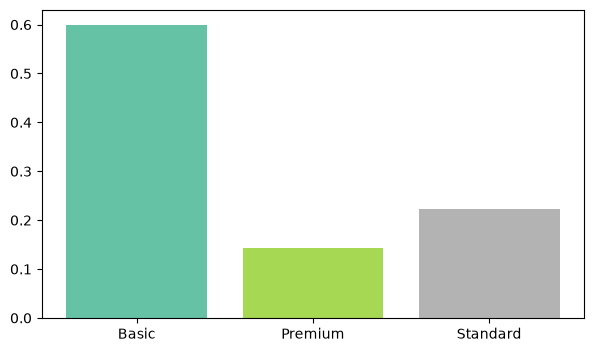

In [108]:
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()
plt.figure(figsize=(7,4))
#color=['purple','yellow','blue']
color=plt.cm.Set2(np.linspace(0,1, len(churn_plan)))
plt.bar(churn_plan.index,churn_plan.values,color=color)
plt.show()

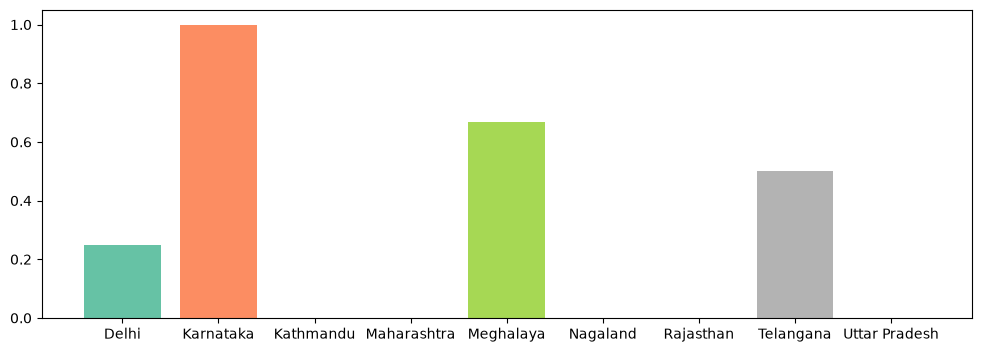

In [109]:
# churn by state
churn_plan = df_visual.groupby('state')['churn_flag'].mean()
plt.figure(figsize=(12,4))
#color=['purple','yellow','blue']
color=plt.cm.Set2(np.linspace(0,1, len(churn_plan)))
plt.bar(churn_plan.index,churn_plan.values,color=color)
plt.show()

In [110]:
# encoding -convert str to numerica so that  we can find corr beetween features
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='str')

In [111]:
df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,0
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [112]:
import warnings
warnings.filterwarning("ignore")

AttributeError: module 'warnings' has no attribute 'filterwarning'

In [ ]:
# incorrect method for encoding - as numbers are nit assigned based on priority
df_encoded = df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']].head()
categorical_cols=['plan_type','contract_type','churn_risk']
for col in categorical_cols:
    df_encoded[col]=df_encoded[col].astype('category').cat.codes

In [ ]:
df_encoded.head()

### visualization by seaborn

In [113]:
# heatmap(correlation matrix)
sns.heatmap(df_encoded.corr(),annot=True)           # 0 to 1  positive correlation  -1 to 0 negative correlation 

NameError: name 'df_encoded' is not defined

In [114]:
# correct method of  encoding - based on priority
df_encoded = df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']].head()
order_mapping={'plan_type':['Basic','Standard','Premium'],		
               'contract_type':['Monthly','Annual'],
               'churn_risk':['low','med','high']    
}
for col,order in order_mapping.items() :
    df_encoded[col]=pd.Categorical(df_encoded[col].astype('category'),categories=order,ordered=True).codes

In [115]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,0
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

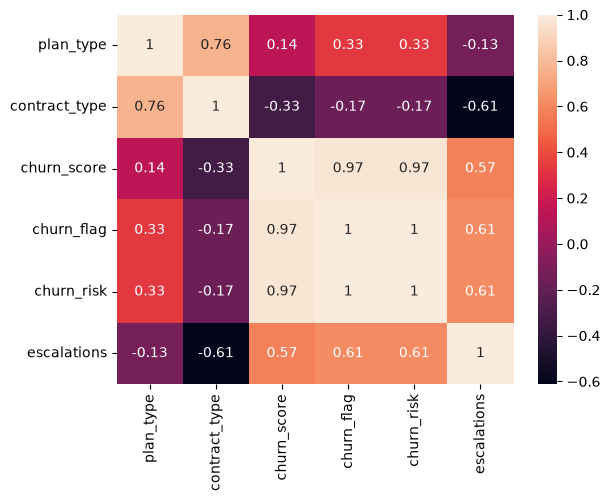

In [116]:
# heatmap(correlation matrix)
sns.heatmap(df_encoded.corr(),annot=True)  

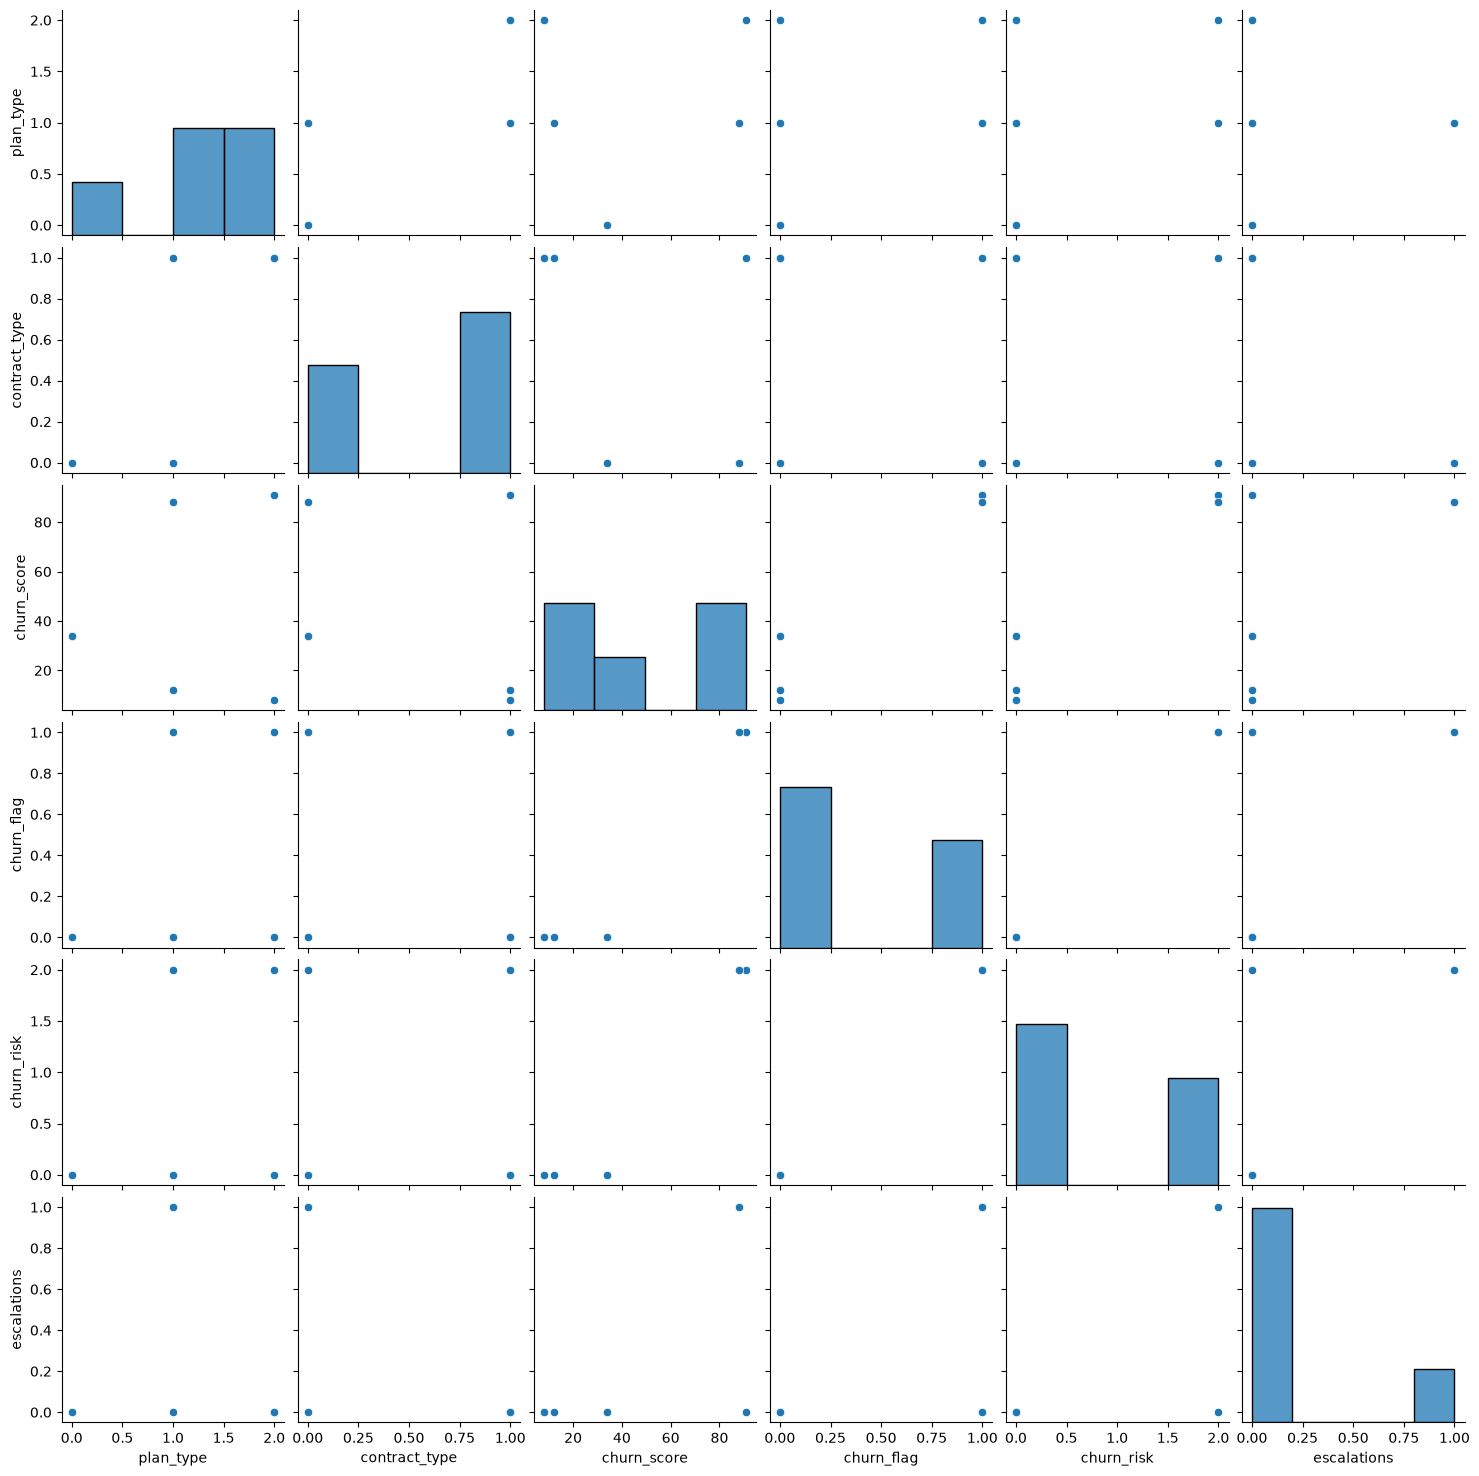

In [117]:
# pairplot - relationship in a dataset
sns.pairplot(df_encoded)

In [118]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='str')

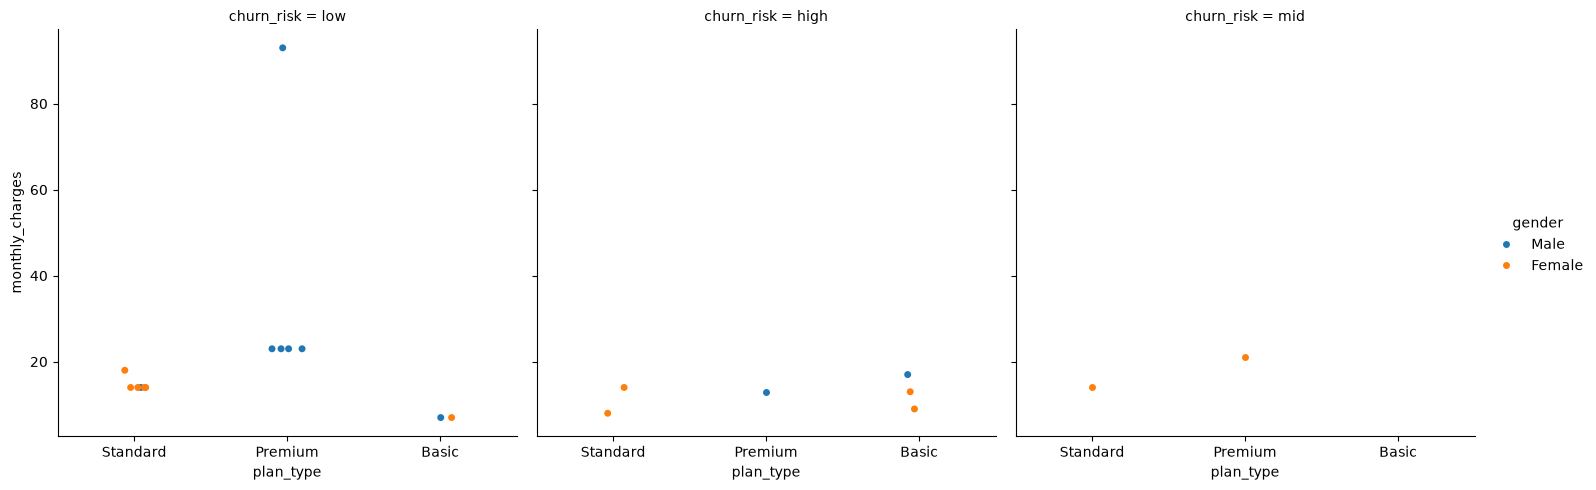

In [119]:
# catplt/facegrid plot - multi -dimension  comparision
sns.catplot(data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk')

In [120]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='str')

### pivot table 

In [121]:
pd.pivot_table(
   df_visual,
    index='plan_type',
    values=['churn_flag','monthly_charges','customerid'],
    aggfunc={
        'customerid':'nunique',
        'monthly_charges':'sum',
        'churn_flag':'mean'
    }
    
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [122]:
# create in sql in python 
# create database 
#conn = sqlite3.connect('test_database.sqlite')
conn.execute("CREATE TABLE users(first_name TEXT, country TEXT,budget integer)")
conn.commit()

ProgrammingError: Cannot operate on a closed database.

In [ ]:
# insert data

cursor = conn.cursor()
cursor.execute(
    """
    INSERT INTO users values
    ('Madhav', 'India', 5000), 
    ('Rishabh', 'India', 7000), 
    ('Vishakha', 'Nepal', 4000) """)
conn.commit()

print("Data inserted successfully!")

In [ ]:
# check inserted data in table 
conn = sqlite3.connect('test_database.sqlite')
query = "SELECT * FROM users"
df = pd.read_sql(query, conn)
print(df.head())

In [ ]:
# Aggregation query using SQL
agg_query = """
SELECT country, SUM(budget) AS total_budget
FROM users
GROUP BY country
"""
df_agg = pd.read_sql(query, conn)
df_agg

In [ ]:
conn.close()

In [124]:
import sqlite3
import pandas as pd

# 1. SQLite Database connect kara
conn = sqlite3.connect('customer_churn.db')

# 2. Database madhil tables read kara
df_customer = pd.read_sql("SELECT * FROM db_customer", conn)
df_subscription = pd.read_sql("SELECT * FROM db_subscription", conn)
df_support = pd.read_sql("SELECT * FROM db_support", conn)

# 3. Support Table deduplicate kara
df_support_clean = df_support.drop_duplicates(subset=['customerid'])

# 4. Tables Merge karun Final Cleaned Dataset banva
df_final = (df_subscription
            .merge(df_customer, on='customerid', how='left')
            .merge(df_support_clean, on='customerid', how='left'))

# 5. CSV file export / save kara
df_final.to_csv("exported_churn_data.csv", index=False)
print("exported_churn_data.csv file tumchya folder madhe save jhali ahe!")

exported_churn_data.csv file tumchya folder madhe save jhali ahe!
